In [1]:
import numpy as np
from cv2 import imread
from matplotlib import pyplot as plt
from skimage.transform import hough_line, hough_line_peaks

from rebar_object_detection import get_bounding_boxes, get_lines

In [2]:
image_path = "data/intersect-detect/test/images/20250620_115012_jpg.rf.239a32ab7bcbefe30fb9f388607d7048.jpg"
model_path = "runs/detect/tune/weights/best.pt"

data = get_lines(image_path, model_path)

[[169.3728, 188.57601928710938], [252.42786, 190.3455047607422]]
[[464.21503, 129.82461547851562], [552.4784, 132.55868530273438]]
[[466.26123, 14.039850234985352], [550.9252, 14.273862838745117]]
[[83.79451, 122.55018615722656], [169.09317, 125.2747802734375]]
[[57.832294, 250.08477783203125], [147.69473, 253.75299072265625]]
[[286.33493, 12.397476196289062], [370.12396, 14.1732759475708]]
[[459.2906, 259.0635070800781], [553.36365, 260.76324462890625]]
[[198.27635, 11.794517517089844], [276.76797, 12.397476196289062]]
[[146.70316, 325.66729736328125], [236.11783, 326.725341796875]]
[[108.24648, 10.019006729125977], [187.57292, 11.794517517089844]]
[[354.13147, 329.0121154785156], [447.09607, 331.7273864746094]]
[[158.17374, 253.75299072265625], [245.30666, 256.0281982421875]]
[[380.66217, 14.1732759475708], [456.74707, 14.039850234985352]]
[[264.14423, 190.3455047607422], [355.33463, 192.39492797851562]]
[[464.72296, 67.82476806640625], [550.50757, 69.07756042480469]]
[[178.89145, 12

In [3]:
image_path = "data/intersect-detect/test/images/20250620_115012_jpg.rf.239a32ab7bcbefe30fb9f388607d7048.jpg"
model_path = "runs/detect/tune/weights/best.pt"

bounding_boxes = get_bounding_boxes(image_path, model_path)
vertices = []
for box in bounding_boxes:
    x_center = (box[0] + box[2]) / 2
    y_center = (box[1] + box[3]) / 2
    vertices.append((x_center, y_center))
vertices = np.array(vertices)

print(vertices)

[[      163.6      188.58]
 [     458.37      129.82]
 [      461.5       14.04]
 [     78.042      122.55]
 [     52.154      250.08]
 [     281.55      12.397]
 [     453.75      259.06]
 [     192.92      11.795]
 [     141.53      325.67]
 [     102.36      10.019]
 [     555.79      69.078]
 [     348.61      329.01]
 [     152.93      253.75]
 [     375.39      14.173]
 [     555.67      14.274]
 [     258.29      190.35]
 [     558.81      260.76]
 [     460.12      67.825]
 [     173.99      125.27]
 [      557.5      132.56]
 [     64.832      186.66]
 [     560.45      333.94]
 [      184.2      63.058]
 [      275.4      65.128]
 [     456.16      193.22]
 [     267.37      126.97]
 [     91.382      62.584]
 [     355.43      257.92]
 [     250.51      256.03]
 [     557.68      196.05]
 [     371.71      67.456]
 [     453.02      331.73]
 [     241.32      326.73]
 [     360.67      192.39]
 [     499.17      548.07]
 [     13.928      9.2189]
 [     366.02      128.67]
 

Detected lines (rho, theta):
(462.0, 0.03490658503988664)
(375.0, 0.0872664625997166)
(190.0, 0.15707963267948966)
(-185.0, -1.5533430342749532)
(298.0, 1.0297442586766543)
(279.0, 0.12217304763960302)
(243.0, 1.0471975511965979)
(102.0, 0.20943951023931962)
(-14.0, -1.5707963267948966)
(-48.0, -0.9075712110370513)
(-60.0, -1.5533430342749532)
(-122.0, -1.5533430342749532)
(-323.0, -1.5533430342749532)


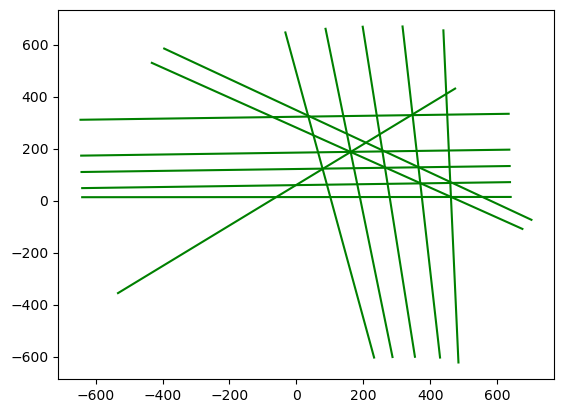

In [4]:
# Rasterize into an image
height, width = imread(image_path).shape[:2]
canvas = np.zeros((height, width), dtype=np.uint8)
for x,y in vertices:
    x_int, y_int = int(x), int(y)
    canvas[y_int, x_int] = 1

# Perform Hough Transform
hspace, angles, dists = hough_line(canvas)

# Find peaks
accum, angles_peaks, dists_peaks = hough_line_peaks(hspace, angles, dists)

print("Detected lines (rho, theta):")
for rho, theta in zip(dists_peaks, angles_peaks):
    a = np.cos(theta)
    b = np.sin(theta)

    x0 = rho * a
    y0 = rho * b
    
    x1 = int(x0 + width * (-b))
    y1 = int(y0 + height * (a))
    x2 = int(x0 - width * (-b))
    y2 = int(y0 - height * (a))

    plt.plot((x1, x2), (y1, y2), '-g')
    
    print((rho, theta))
    